# 01 — EDA

Mô tả 3 nguồn dữ liệu chính của ShelfSense **trước khi** vào phần model: catalog sản phẩm, training set detection (SKU-110K), và khoảng cách (domain gap) giữa ảnh train với ảnh thật production. Đây là notebook để EDA — không train, không đo accuracy model. Kết quả detection (so YOLOv8n vs YOLO26n) nằm ở `compare-yolov8n-vs-yolo26n.ipynb` và `yolo26n-on-sku-110k.ipynb`; kết quả classification nằm ở `03_classification_eval.ipynb`.

Nguồn dữ liệu dùng trong notebook này:
- `data/catalog/catalog_seed.csv` — catalog 144 SKU, đọc trực tiếp.

- `docs/detection-notes/detection-log.md` (phần "Phụ lục: Schema 2 dataset SKU-110K") và `docs/reports/model-research-summary.md` (mục 1) — số liệu SKU-110K, **trích lại từ 2 file này, không tải dataset**. SKU-110K train split có 8219 ảnh.

- `data/scan_viz/input/test1.HEIC` … `test22.HEIC` — 22 ảnh thật tự chụp, cùng `data/scan_viz/review.xlsx` (mỗi dòng trong 1 sheet = 1 box đã detect được trên ảnh đó, đếm lại chứ không chạy lại detection).

- `data/scan_viz/eval_sample_selection.xlsx` — eval set 150 dòng, đọc lại sheet dữ liệu + README.

Mọi số liệu về SKU-110K trong notebook đều kèm trích dẫn file + dòng.

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

REPO_ROOT

PosixPath('/Users/realzoey/Project/shelf-stock-monitoring')

## 1. Catalog overview

Catalog hiện có **144 SKU cố định** (`data/catalog/catalog_seed.csv`). Đây là **closed-set**: hệ thống classification (SigLIP2 zero-shot + LLM verify, xem `03_classification_eval.ipynb`) chỉ nhận diện được sản phẩm nằm trong 144 SKU này — sản phẩm ngoài danh sách sẽ rơi vào nhóm "catalog-gap", không phải open-vocabulary classification.

In [2]:
catalog_df = pd.read_csv("data/catalog/catalog_seed.csv")
print(f"Tổng số SKU: {len(catalog_df)}")
assert len(catalog_df) == 144, "catalog không còn đúng 144 SKU như spec ban đầu"

category_counts = catalog_df["Nhóm"].value_counts()
category_counts.rename("n_sku").to_frame()

Tổng số SKU: 144


,n_sku
Nhóm,
Sữa & sản phẩm từ sữa,48
Mì/cháo/phở ăn liền,44
Nước giải khát có ga,21
Nước uống không ga / nước suối,18
Bánh kẹo,10
Snack/đồ ăn vặt,2
Chăm sóc nhà cửa,1


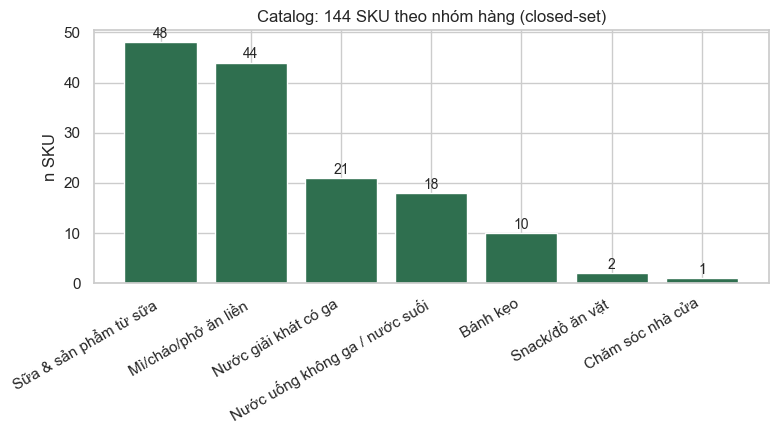

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(category_counts.index, category_counts.values, color="#2f6f4f")
for bar, v in zip(bars, category_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.8, str(v), ha="center", fontsize=10)

ax.set_ylabel("n SKU")
ax.set_xlabel("")
ax.set_title("Catalog: 144 SKU theo nhóm hàng (closed-set)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Comment:** catalog lệch mạnh về 2 nhóm Sữa (48 SKU) và Mì/cháo/phở ăn liền (44 SKU) - 2 nhóm này đã chiếm 92/144 = 63.9% catalog. Nước có ga (21 SKU) đứng thứ 3, các nhóm còn lại (Nước không ga, Bánh kẹo, Snack, Chăm sóc nhà cửa) rất mỏng, có nhóm chỉ 1-2 SKU. Riêng 3 nhóm dày nhất (Sữa + Mì gói + Nước có ga) cộng lại chiếm 113/144 = 78.5% catalog, đây cũng là lý do phần Eval set overview ở cuối notebook chỉ tập trung lấy mẫu 3 nhóm này: nhóm quá mỏng (1-2 SKU) không đủ dữ liệu để đánh giá có ý nghĩa thống kê.

## 2. Training set overview: SKU-110K

Dataset dùng để train model detect production (YOLO26n), đã convert sẵn sang format YOLO, gồm 3 phần: **train 8185 ảnh, validation 584 ảnh, test 2920 ảnh**. Đây là ảnh chụp kệ hàng siêu thị, mật độ vật thể/ảnh rất dày.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")

In [2]:
DATASET_ROOT = Path("/kaggle/input/datasets/thedatasith/sku110k-annotations/SKU110K_fixed")
assert DATASET_ROOT.exists(), (
    f"Không tìm thấy {DATASET_ROOT} -- kiểm tra lại đã Add Data đúng dataset chưa, "
    "hoặc path thật khác (xem panel bên phải Kaggle, mục Input)."
)

print("Cấu trúc thư mục (2 cấp, không quét sâu hơn để tránh chậm):")
for root, dirs, files in os.walk(DATASET_ROOT):
    depth = len(Path(root).relative_to(DATASET_ROOT).parts)
    if depth > 2:
        dirs[:] = []
        continue
    indent = "  " * depth
    print(f"{indent}{Path(root).name}/  ({len(files)} file{'s' if len(files) != 1 else ''})")
    if files:
        print(f"{indent}  vd: {sorted(files)[:3]}")

Cấu trúc thư mục (2 cấp, không quét sâu hơn để tránh chậm):
SKU110K_fixed/  (0 files)
  labels/  (0 files)
    val/  (584 files)
      vd: ['val_0.txt', 'val_1.txt', 'val_10.txt']
    test/  (2920 files)
      vd: ['test_0.txt', 'test_1.txt', 'test_10.txt']
    train/  (8185 files)
      vd: ['train_0.txt', 'train_1.txt', 'train_10.txt']
  images/  (0 files)
    val/  (584 files)
      vd: ['val_0.jpg', 'val_1.jpg', 'val_10.jpg']
    test/  (2920 files)
      vd: ['test_0.jpg', 'test_1.jpg', 'test_10.jpg']
    train/  (8185 files)
      vd: ['train_0.jpg', 'train_1.jpg', 'train_10.jpg']


In [3]:
LABELS_DIR = DATASET_ROOT / "labels" / "train"
IMAGES_DIR = DATASET_ROOT / "images" / "train"

assert LABELS_DIR.exists(), f"{LABELS_DIR} không tồn tại -- sửa lại theo cấu trúc thật"
assert IMAGES_DIR.exists(), f"{IMAGES_DIR} không tồn tại -- sửa lại theo cấu trúc thật"

label_files = sorted(LABELS_DIR.glob("*.txt"))
print(f"Số file label tìm thấy: {len(label_files)}")
assert len(label_files) > 0, "Không tìm thấy .txt nào -- kiểm tra lại LABELS_DIR"

Số file label tìm thấy: 8185


### 2.1 Mật độ vật thể/ảnh   

In [4]:
def count_objects(label_path):
    with open(label_path) as f:
        return sum(1 for line in f if line.strip())

objects_per_image = pd.Series(
    [count_objects(lf) for lf in label_files], name="n_objects"
)
print(objects_per_image.describe())

count    8185.000000
mean      147.008919
std        42.739776
min         1.000000
25%       123.000000
50%       138.000000
75%       161.000000
max       576.000000
Name: n_objects, dtype: float64


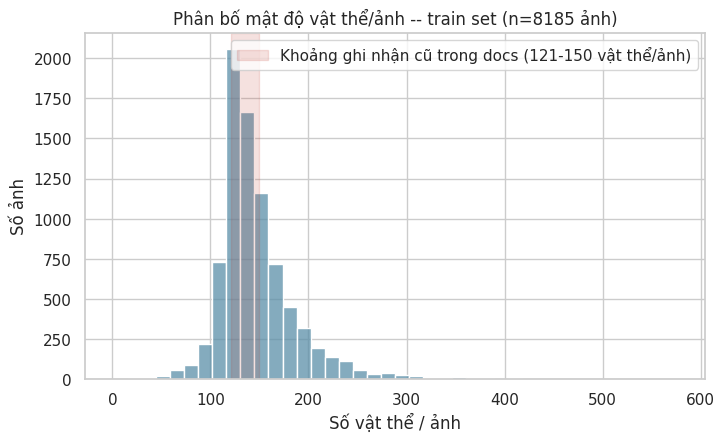

Trung vị: 138 | Trung bình: 147.0 | Min-Max: 1-576


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(objects_per_image, bins=40, ax=ax, color="#5b8fa8")
ax.axvspan(121, 150, color="#c0392b", alpha=0.15,
           label="Khoảng ghi nhận cũ trong docs (121-150 vật thể/ảnh)")
ax.set_xlabel("Số vật thể / ảnh")
ax.set_ylabel("Số ảnh")
ax.set_title(f"Phân bố mật độ vật thể/ảnh -- train set (n={len(objects_per_image)} ảnh)")
ax.legend()
plt.show()

print(f"Trung vị: {objects_per_image.median():.0f} | Trung bình: {objects_per_image.mean():.1f} "
      f"| Min-Max: {objects_per_image.min()}-{objects_per_image.max()}")

**Comment:** trung bình 147 vật thể/ảnh, trung vị 138, khoảng giữa (25%-75%) là 123-161 vật thể/ảnh, cho thấy dữ liệu train rất dày đặc, có ảnh lên tới 576 vật thể. Mật độ cao này là lý do model detect chưa fine-tune ban đầu (dùng thẳng model có sẵn, không train riêng) cho kết quả rất kém trên ảnh dạng này: quá nhiều vật thể chồng chéo sát nhau để model chung nhận diện tốt, phải fine-tune riêng cho đúng bài toán này.

### 2.2 Kích thước & tỷ lệ khung bbox

Đo kích thước thật (theo pixel trên ảnh gốc, không phải tỉ lệ chuẩn hoá 0-1 trong file label) của các khung bao quanh vật thể trong tập train — sample 2000/8185 ảnh cho đỡ chậm, đủ đại diện để xem phân bố hình dạng.

In [6]:
SAMPLE_N = 2000
random.seed(42)
sampled_label_files = random.sample(label_files, min(SAMPLE_N, len(label_files)))

records = []
n_skipped = 0
for lf in sampled_label_files:
    img_path = IMAGES_DIR / f"{lf.stem}.jpg"
    if not img_path.exists():
        n_skipped += 1
        continue
    with Image.open(img_path) as im:
        img_w, img_h = im.size
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, cx, cy, nw, nh = parts
            nw, nh = float(nw), float(nh)
            records.append({
                "img_w": img_w, "img_h": img_h,
                "norm_w": nw, "norm_h": nh,
                "abs_w_px": nw * img_w, "abs_h_px": nh * img_h,
                "aspect_ratio": (nw / nh) if nh > 0 else None,
            })

bbox_df = pd.DataFrame(records)
print(f"Số box lấy mẫu: {len(bbox_df)} (từ {len(sampled_label_files) - n_skipped}/{len(sampled_label_files)} ảnh, "
      f"{n_skipped} ảnh bị bỏ qua vì không tìm thấy file ảnh khớp tên -- nếu số này lớn, "
      f"kiểm tra lại quy ước đặt tên ảnh/label có khớp nhau không)")
bbox_df[["abs_w_px", "abs_h_px", "aspect_ratio"]].describe()

Số box lấy mẫu: 293068 (từ 2000/2000 ảnh, 0 ảnh bị bỏ qua vì không tìm thấy file ảnh khớp tên -- nếu số này lớn, kiểm tra lại quy ước đặt tên ảnh/label có khớp nhau không)


,abs_w_px,abs_h_px,aspect_ratio
count,293068.000000,293068.000000,293068.000000
mean,121.380403,190.029447,1.286299
std,72.804407,96.445439,1.549408
min,21.000000,21.000000,0.054878
25%,74.000000,113.000000,0.447811
50%,103.000000,180.000000,0.708709
75%,147.000000,253.000000,1.474638
max,2226.000000,1835.000000,27.474747


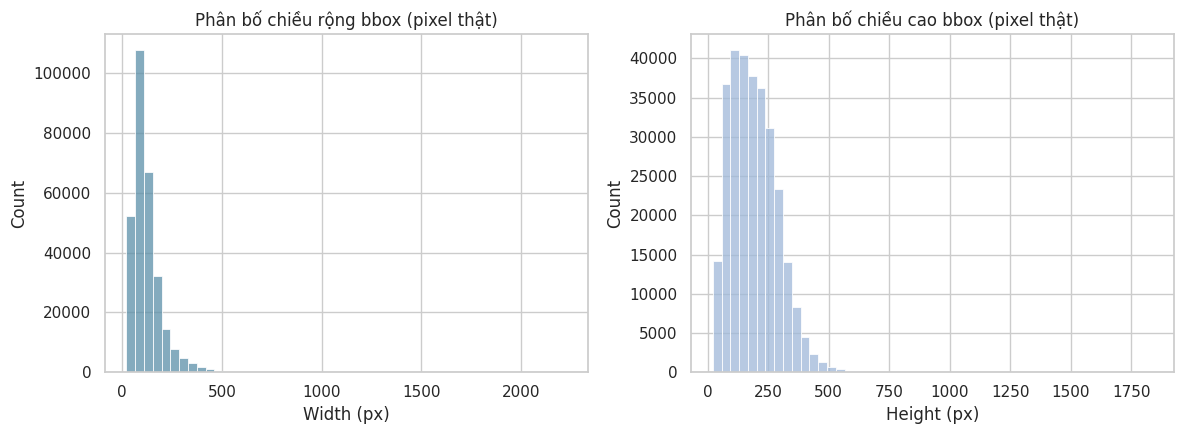

% box được coi là 'small object' (diện tích < 32x32px, ngưỡng tham khảo COCO): 0.1%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(bbox_df["abs_w_px"], bins=50, ax=axes[0], color="#5b8fa8")
axes[0].set_title("Phân bố chiều rộng bbox (pixel thật)")
axes[0].set_xlabel("Width (px)")

sns.histplot(bbox_df["abs_h_px"], bins=50, ax=axes[1], color="#9fb8d9")
axes[1].set_title("Phân bố chiều cao bbox (pixel thật)")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.show()

# Ngưỡng "small object" tham khảo theo convention COCO (area < 32x32px) -- không phải
# luật cứng của project, chỉ dùng để có 1 con số cụ thể minh hoạ mức độ "nhỏ".
bbox_df["area_px"] = bbox_df["abs_w_px"] * bbox_df["abs_h_px"]
small_object_area_px = 32 * 32
pct_small = (bbox_df["area_px"] < small_object_area_px).mean()
print(f"% box được coi là 'small object' (diện tích < 32x32px, ngưỡng tham khảo COCO): {pct_small:.1%}")

**Comment:**

Chỉ 0.1% khung bbox có diện tích dưới 32×32px (ngưỡng "vật thể nhỏ" tham khảo theo chuẩn COCO) —> tức đại đa số vật thể trong ảnh train KHÔNG nhỏ nếu tính trên đúng độ phân giải gốc (chiều rộng trung vị 103px, chiều cao trung vị 180px).

Điều này ban đầu nghe có vẻ ngược với việc dataset dạng này (kệ hàng dày đặc) thường được coi là bài toán "vật thể nhỏ" nhưng lý do nằm ở bước tiếp theo trong pipeline thật: ảnh gốc có độ phân giải rất lớn (xem mục 2.4 bên dưới, trung bình khoảng 2700×3200px), trong khi hệ thống resize ảnh về 640px trước khi đưa vào model detect.

Ước tính nhanh (chưa phải số đo trực tiếp): nếu ảnh ~3000px bị resize còn 640px (tỉ lệ ~1/5), khung bbox trung vị 103×180px trên ảnh gốc sẽ co lại còn khoảng 20×36px sau resize, lúc đó mới thật sự rơi vào ngưỡng "nhỏ". Nói cách khác: vật thể không nhỏ sẵn trong dữ liệu gốc, mà bị bước resize của pipeline làm cho nhỏ đi.

### 3. Kiểm tra số class thật

In [8]:
class_ids = []
for lf in label_files:
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                class_ids.append(parts[0])

class_counts = pd.Series(class_ids).value_counts()
print("Phân bố class_id thật trong toàn bộ train set:")
print(class_counts)

Phân bố class_id thật trong toàn bộ train set:
0    1203268
Name: count, dtype: int64


**Comment:** toàn bộ 1.203.268 khung bbox trong tập train chỉ có ĐÚNG 1 class_id (`0`). Xác nhận chắc chắn dataset này chỉ phát hiện "có sản phẩm ở đây hay không" (localization), hoàn toàn không phân biệt được đó là sản phẩm/SKU cụ thể nào. Đây là lý do hệ thống cần một bước riêng biệt SAU detect để xác định đúng SKU (dựa trên so khớp hình ảnh + xác minh), bản thân model detect không hề được dạy để phân biệt các SKU khác nhau, việc này nằm ngoài khả năng của nó.

### 2.4 Phân bố resolution ảnh gốc

*(Lưu ý: bảng thống kê dưới chỉ tính trên 35 giá trị resolution khác nhau tìm thấy trong sample 2000 ảnh ở mục 2.2, tức là các MỨC resolution xuất hiện, không phải trung bình có trọng số theo tần suất từng ảnh.)*

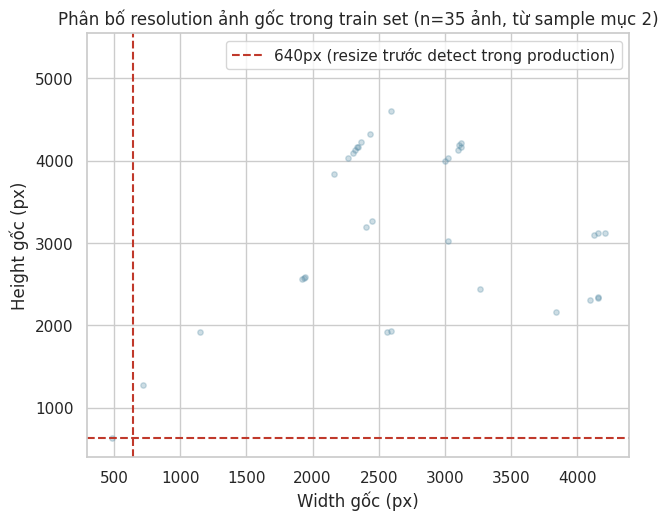

             img_w        img_h
count    35.000000    35.000000
mean   2736.057143  3241.028571
std     934.913458  1066.730394
min     480.000000   640.000000
25%    2313.000000  2394.000000
50%    2592.000000  3200.000000
75%    3120.000000  4144.000000
max    4208.000000  5312.000000


In [9]:
res_df = bbox_df[["img_w", "img_h"]].drop_duplicates()

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(res_df["img_w"], res_df["img_h"], alpha=0.3, s=15, color="#5b8fa8")
ax.axvline(640, color="#c0392b", linestyle="--", label="640px (resize trước detect trong production)")
ax.axhline(640, color="#c0392b", linestyle="--")
ax.set_xlabel("Width gốc (px)")
ax.set_ylabel("Height gốc (px)")
ax.set_title(f"Phân bố resolution ảnh gốc trong train set (n={len(res_df)} ảnh, từ sample mục 2)")
ax.legend()
plt.show()

print(res_df.describe())

**Comment:** ảnh gốc trong tập train có độ phân giải rất lớn, trung bình khoảng 2700×3200px, cao nhất tới 4208×5312px, thấp nhất cũng 480×640px. Trong khi đó, pipeline production hiện resize ảnh về 640px trước khi detect -> ảnh gốc bị thu nhỏ đi nhiều lần trước khi model nhìn thấy.

## 3. Domain-gap analysis: SKU-110K (train) vs ảnh thật (test)

### 3.1 Mật độ vật thể/ảnh

Đếm số box thật đã detect được trên 22 ảnh thật (mỗi ảnh 1 sheet, mỗi dòng trong sheet là 1 box), không chạy lại detection, chỉ đếm lại kết quả đã có sẵn.

In [4]:
def count_boxes_per_sheet(path="data/scan_viz/review.xlsx"):
    wb = openpyxl.load_workbook(path, read_only=True)
    counts = {}
    for name in wb.sheetnames:
        ws = wb[name]
        n = sum(1 for row in ws.iter_rows(min_row=2, values_only=True) if any(c is not None for c in row))
        counts[name] = n
    wb.close()
    return counts


box_counts = count_boxes_per_sheet()
density_df = pd.DataFrame(
    sorted(box_counts.items(), key=lambda kv: int(kv[0].replace("test", ""))),
    columns=["image", "n_boxes"],
)
density_df

,image,n_boxes
0,test1,54
1,test2,86
2,test3,37
3,test4,38
4,test5,50
5,test6,35
6,test7,58
7,test8,62
8,test9,46
9,test10,54


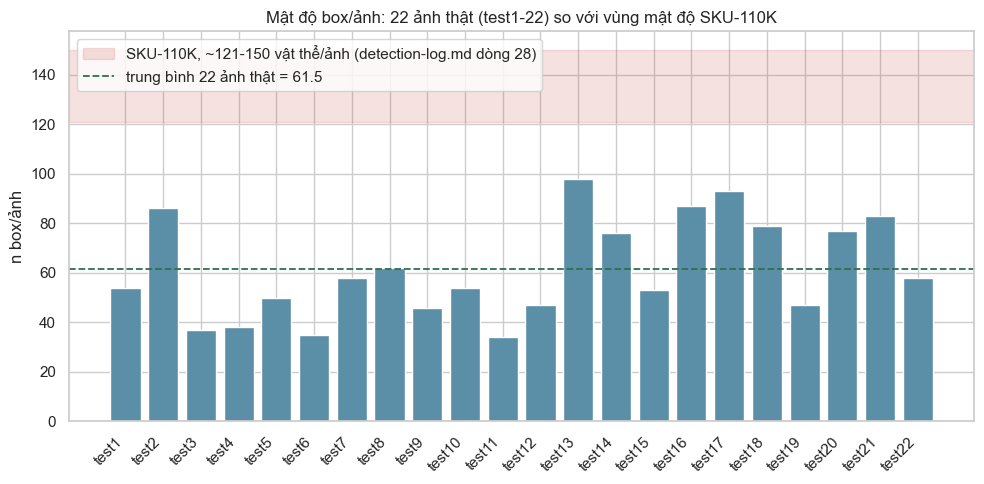

22 ảnh thật: min=34, median=56, mean=61.5, max=98
SKU-110K (nguồn detection-log.md dòng 28): ~121-150 vật thể/ảnh


In [5]:
SKU110K_DENSITY_LOW, SKU110K_DENSITY_HIGH = 121, 150  # docs/detection-notes/detection-log.md, dòng 28

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(density_df["image"], density_df["n_boxes"], color="#5b8fa8")
ax.axhspan(SKU110K_DENSITY_LOW, SKU110K_DENSITY_HIGH, color="#c0392b", alpha=0.15,
           label=f"SKU-110K, ~{SKU110K_DENSITY_LOW}-{SKU110K_DENSITY_HIGH} vật thể/ảnh (detection-log.md dòng 28)")
mean_real = density_df["n_boxes"].mean()
ax.axhline(mean_real, color="#2f6f4f", linestyle="--", linewidth=1.3,
           label=f"trung bình 22 ảnh thật = {mean_real:.1f}")

ax.set_ylabel("n box/ảnh")
ax.set_xlabel("")
ax.set_title("Mật độ box/ảnh: 22 ảnh thật (test1-22) so với vùng mật độ SKU-110K")
ax.legend(loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"22 ảnh thật: min={density_df['n_boxes'].min()}, "
      f"median={density_df['n_boxes'].median():.0f}, "
      f"mean={mean_real:.1f}, max={density_df['n_boxes'].max()}")
print(f"SKU-110K (nguồn detection-log.md dòng 28): ~{SKU110K_DENSITY_LOW}-{SKU110K_DENSITY_HIGH} vật thể/ảnh")

**Comment:** mật độ vật thể trong 22 ảnh thật thấp hơn hẳn ảnh train. Ảnh train (đo ở mục 2.1) có trung vị 138 vật thể/ảnh, khoảng giữa 123-161. Trong khi đó, 22 ảnh thật chỉ trung bình 61.5 vật thể/ảnh (thấp nhất 34, cao nhất 98), ảnh thật DÀY NHẤT (`test13`, 98 box) vẫn thấp hơn cả cận dưới (123) của khoảng giữa ảnh train. Trung bình ảnh thật chỉ bằng khoảng 44% trung vị ảnh train (61.5/138 ≈ 44%).

Nói cách khác: ảnh dùng để train model thưa gấp hơn 2 lần ảnh production thật sẽ gặp khi dùng sản phẩm. Đây là một dạng domain-gap cụ thể, không chỉ là ảnh khác kệ, khác quốc gia, mà còn khác cả mức độ dày đặc, ảnh hưởng trực tiếp tới việc model có tổng quát hoá tốt sang ảnh thật hay không.

### 3.2 Khác biệt bối cảnh chụp

Đây là giới hạn đã biết trước:

- **SKU-110K:** ảnh siêu thị nước ngoài, nhiều khả năng chụp trong điều kiện có kiểm soát tốt hơn ảnh chụp tay ngẫu nhiên (dataset công khai chuẩn cho research, xem mục 2).

- **22 ảnh thật (`test1-22.HEIC`):**  tự chụp bằng điện thoại, kệ hàng Việt Nam thật, nhiều góc nghiêng, ánh sáng, che khuất thay đổi theo từng ảnh, không có setup máy cố định.

## 4. Eval set overview (150 dòng)

`data/scan_viz/eval_sample_selection.xlsx` là eval set 150 dòng dùng để đo classification (chi tiết đầy đủ + accuracy ở `03_classification_eval.ipynb`). Notebook này chỉ mô tả cấu trúc dữ liệu, không lặp lại phân tích accuracy.

Theo sheet `README` trong file gốc: 150 dòng lấy stratified random theo category (không theo ảnh) từ pool `test3`-`test19` + 3 ảnh kệ Sữa tự chụp mới (`test20`-`test22`), gộp thành 3 batch theo thời điểm lấy mẫu — batch 1 (52 dòng, Mì gói + Nước có ga, lấy đầu tiên), batch 2 (78 dòng, mở rộng thêm 2 category trên), batch 3 (20 dòng, riêng Sữa từ test20-22).

In [6]:
def load_eval_sample_selection(path="data/scan_viz/eval_sample_selection.xlsx"):
    wb = openpyxl.load_workbook(path, data_only=True)
    ws = wb["eval_sample_selection"]
    rows = list(ws.iter_rows(values_only=True))
    header, data = rows[0], rows[1:]
    return pd.DataFrame(data, columns=header)


eval_df = load_eval_sample_selection()
print(f"Tổng số dòng: {len(eval_df)}")
assert len(eval_df) == 150

batch_counts = eval_df["batch"].value_counts().sort_index()
batch_counts.rename("n_rows").to_frame()

Tổng số dòng: 150


,n_rows
batch,
1,52
2,78
3,20


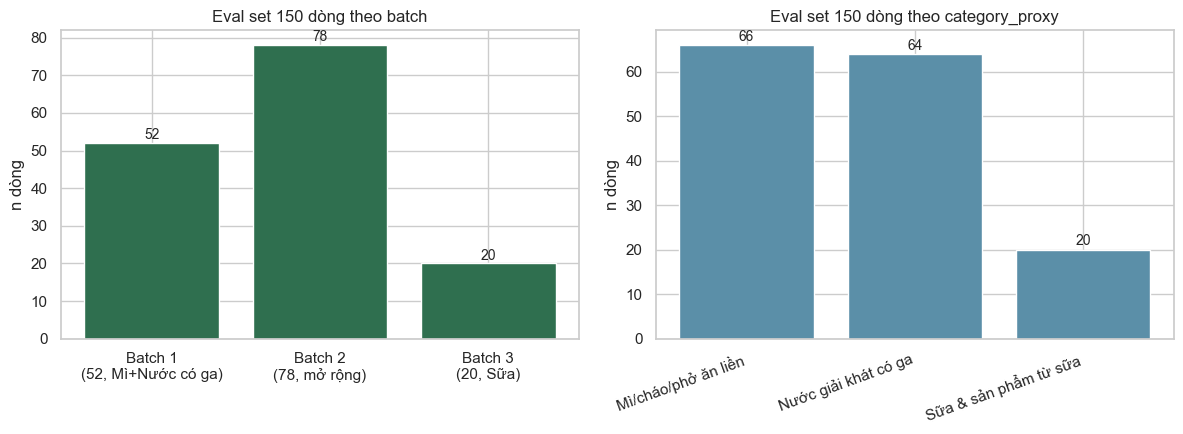

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

batch_labels = {1: "Batch 1\n(52, Mì+Nước có ga)", 2: "Batch 2\n(78, mở rộng)", 3: "Batch 3\n(20, Sữa)"}
ax = axes[0]
bars = ax.bar([batch_labels[b] for b in batch_counts.index], batch_counts.values, color="#2f6f4f")
for bar, v in zip(bars, batch_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v), ha="center", fontsize=10)
ax.set_ylabel("n dòng")
ax.set_title("Eval set 150 dòng theo batch")

cat_counts = eval_df["category_proxy"].value_counts()
ax = axes[1]
bars = ax.bar(cat_counts.index, cat_counts.values, color="#5b8fa8")
for bar, v in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v), ha="center", fontsize=10)
ax.set_ylabel("n dòng")
ax.set_title("Eval set 150 dòng theo category_proxy")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

**Lưu ý về `category_proxy`:** đây là category suy từ `predicted_sku_id` của model (hoặc category đa số của cả sheet nếu dòng đó unknown) — dùng để lấy mẫu cân bằng lúc sample, **không phải nhãn thật**. Category thật (suy từ `true_sku_id` sau khi label thủ công) và toàn bộ số liệu accuracy nằm ở `03_classification_eval.ipynb` mục 2 trở đi.

## 5. Tóm tắt

- **Catalog:** 144 SKU cố định, closed-set. Lệch mạnh về Sữa (48) và Mì gói (44) — cùng
  Nước có ga (21) chiếm 78.5% catalog.
- **Training set (SKU-110K):** 8185 ảnh train thật, mật độ trung bình 147 vật thể/ảnh
  (rất dày đặc), chỉ 1 class duy nhất (không phân biệt SKU). Ảnh gốc độ phân giải lớn
  (~2700×3200px), bị resize còn 640px trước detect — vật thể không nhỏ sẵn nhưng bị làm
  nhỏ đi bởi bước resize này.
- **Domain gap:** 22 ảnh thật thưa hơn ảnh train đáng kể — trung bình chỉ bằng ~44% mật
  độ trung vị ảnh train.
- **Eval set:** 150 dòng, chia 3 batch (52/78/20), tập trung vào 3 nhóm SKU dày nhất
  trong catalog (Mì gói, Nước có ga, Sữa).